# Lasso: Regrese s L1 regularizací

## Co je Lasso?

Lasso (Least Absolute Shrinkage and Selection Operator) je regresní metoda, která provádí regularizaci a výběr příznaků současně. Hlavním znakem Lasso regrese je, že využívá L1 regularizaci, která některé koeficienty modelu nastavuje přesně na nulu.

### Matematická formulace:

Lasso minimalizuje následující funkci:

$$\min_{\beta} \frac{1}{2n} \|y - X\beta\|_2^2 + \alpha \|\beta\|_1$$

kde:
- $y$ je vektor cílových hodnot
- $X$ jsou vstupní příznaky
- $\beta$ jsou koeficienty modelu
- $\alpha$ je parametr regularizace (síla penalizace)
- $\|\beta\|_1$ je L1 norma koeficientů (suma absolutních hodnot)

### Klíčové vlastnosti Lasso:

1. **Výběr příznaků (feature selection)** - Automaticky nastavuje nevýznamné koeficienty přesně na nulu
2. **Řídké modely (sparsity)** - Vytváří modely využívající jen podmnožinu dostupných příznaků
3. **Regularizace** - Omezuje velikost koeficientů a tím snižuje přeučení
4. **Interpretabilita** - Zjednodušuje model identifikací nejdůležitějších příznaků

### Kdy použít Lasso:

- Když máte mnoho příznaků a chcete vybrat jen ty nejdůležitější
- Když řešíte problém s vysokou dimenzionalitou
- Když je důležitá interpretace modelu
- Když předpokládáte, že mnoho příznaků je irelevantních

In [1]:
# Import potřebných knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.pipeline import Pipeline
import time

# Nastavení vizualizací
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Pro reprodukovatelnost výsledků
np.random.seed(42)

## 1. Demonstrace základních vlastností Lasso

Nejprve vytvoříme syntetický dataset, kde jen několik příznaků je skutečně užitečných pro predikci. To nám umožní lépe pozorovat, jak Lasso vybírá příznaky.

Dataset: 150 trénovacích vzorků, 50 testovacích vzorků, 50 příznaků
Skutečný počet informativních příznaků: 5


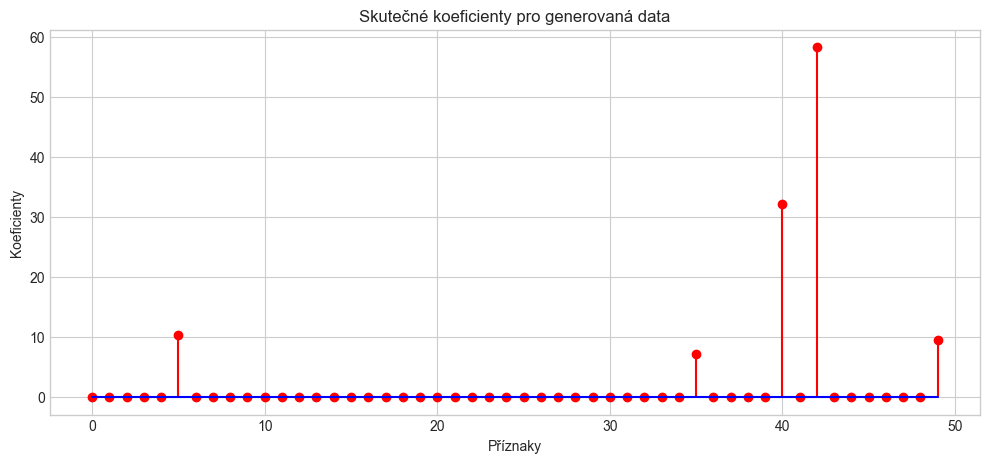

In [2]:
# Vytvoření syntetického datasetu s řídkou strukturou
n_samples, n_features = 200, 50
n_informative = 5  # Pouze 5 příznaků bude mít skutečný vliv

X, y, true_coef = make_regression(n_samples=n_samples, 
                                 n_features=n_features,
                                 n_informative=n_informative,
                                 coef=True,
                                 noise=10,
                                 random_state=42)

# Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardizace dat
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset: {X_train.shape[0]} trénovacích vzorků, {X_test.shape[0]} testovacích vzorků, {X_train.shape[1]} příznaků")
print(f"Skutečný počet informativních příznaků: {n_informative}")

# Vizualizace skutečných koeficientů
plt.figure(figsize=(12, 5))
plt.stem(range(n_features), true_coef, markerfmt='ro', linefmt='r-', basefmt='b-')
plt.xlabel('Příznaky')
plt.ylabel('Koeficienty')
plt.title('Skutečné koeficienty pro generovaná data')
plt.grid(True)
plt.show()

In [3]:
# Trénování Lasso modelu s různými hodnotami regularizačního parametru
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
lasso_models = {}
coefs = []

for alpha in alphas:
    # Trénování modelu
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    
    # Uložení modelu a koeficientů
    lasso_models[alpha] = lasso
    coefs.append(lasso.coef_)
    
    # Predikce a výpočet metriky
    y_pred = lasso.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Výpočet počtu nenulových koeficientů
    n_nonzero = np.sum(lasso.coef_ != 0)
    
    print(f"Alpha = {alpha}:")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  Počet nenulových koeficientů: {n_nonzero} (z celkových {n_features})")

Alpha = 0.0001:
  MSE: 159.7816
  R²: 0.9690
  Počet nenulových koeficientů: 50 (z celkových 50)
Alpha = 0.001:
  MSE: 159.6377
  R²: 0.9691
  Počet nenulových koeficientů: 50 (z celkových 50)
Alpha = 0.01:
  MSE: 158.2281
  R²: 0.9693
  Počet nenulových koeficientů: 50 (z celkových 50)
Alpha = 0.1:
  MSE: 148.2658
  R²: 0.9713
  Počet nenulových koeficientů: 43 (z celkových 50)
Alpha = 1.0:
  MSE: 114.9781
  R²: 0.9777
  Počet nenulových koeficientů: 13 (z celkových 50)
Alpha = 10.0:
  MSE: 675.7642
  R²: 0.8690
  Počet nenulových koeficientů: 2 (z celkových 50)


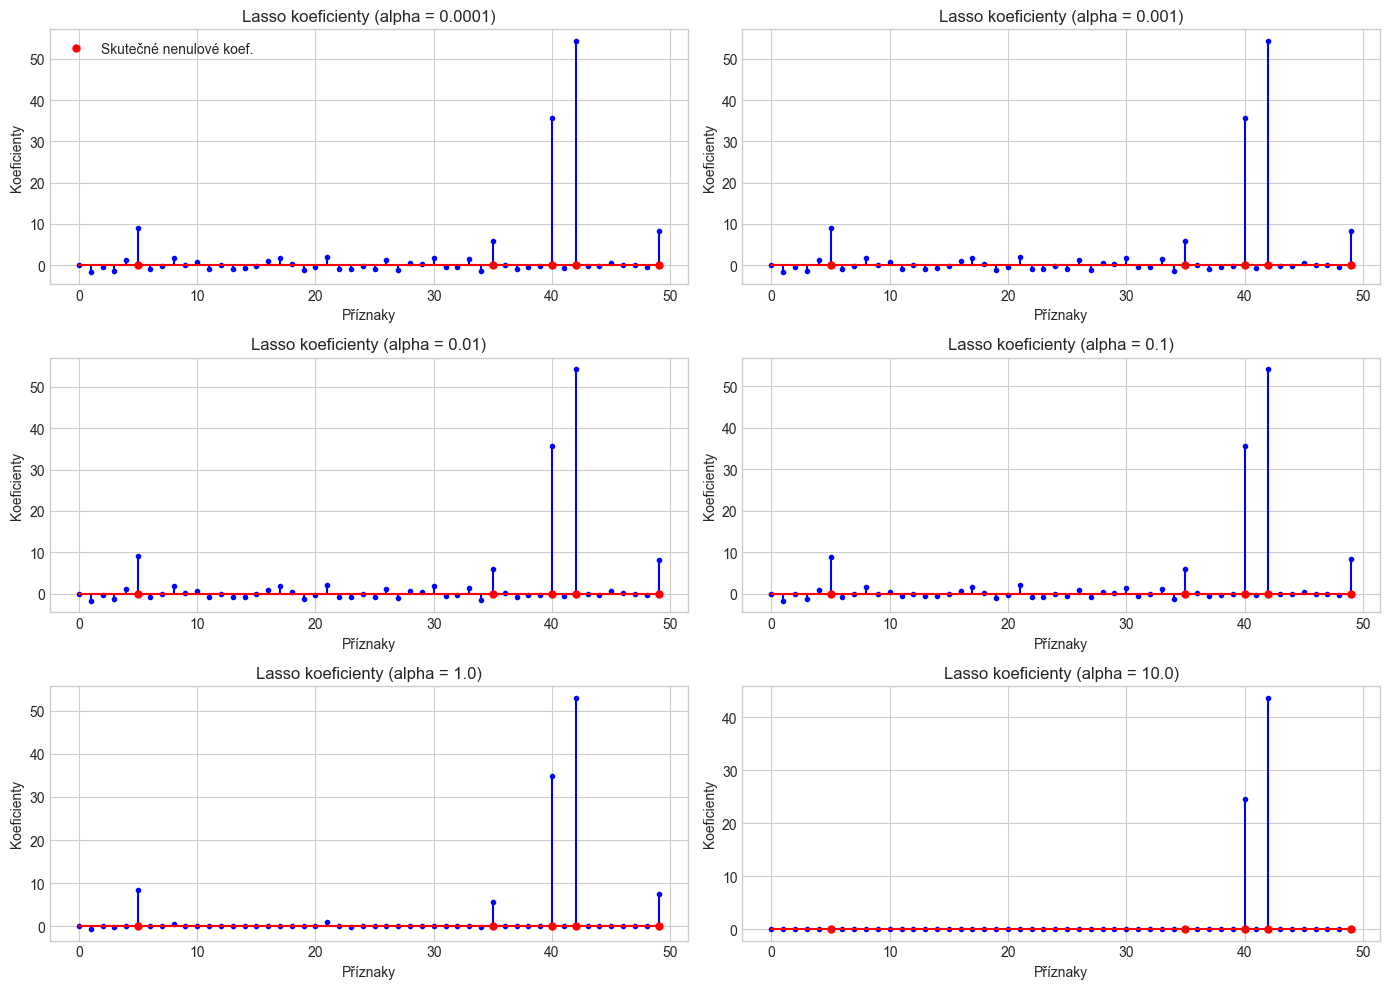

In [4]:
# Vizualizace koeficientů pro různé hodnoty alpha
plt.figure(figsize=(14, 10))

# Příprava informace o skutečných koeficientech
true_nonzero = np.where(true_coef != 0)[0]

for i, alpha in enumerate(alphas):
    plt.subplot(3, 2, i+1)
    plt.stem(range(n_features), coefs[i], markerfmt='.', linefmt='b-', basefmt='r-')
    
    # Zvýraznění skutečných nenulových koeficientů
    plt.plot(true_nonzero, [0]*len(true_nonzero), 'ro', markersize=5, label='Skutečné nenulové koef.')
    
    plt.xlabel('Příznaky')
    plt.ylabel('Koeficienty')
    plt.title(f'Lasso koeficienty (alpha = {alpha})')
    plt.grid(True)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

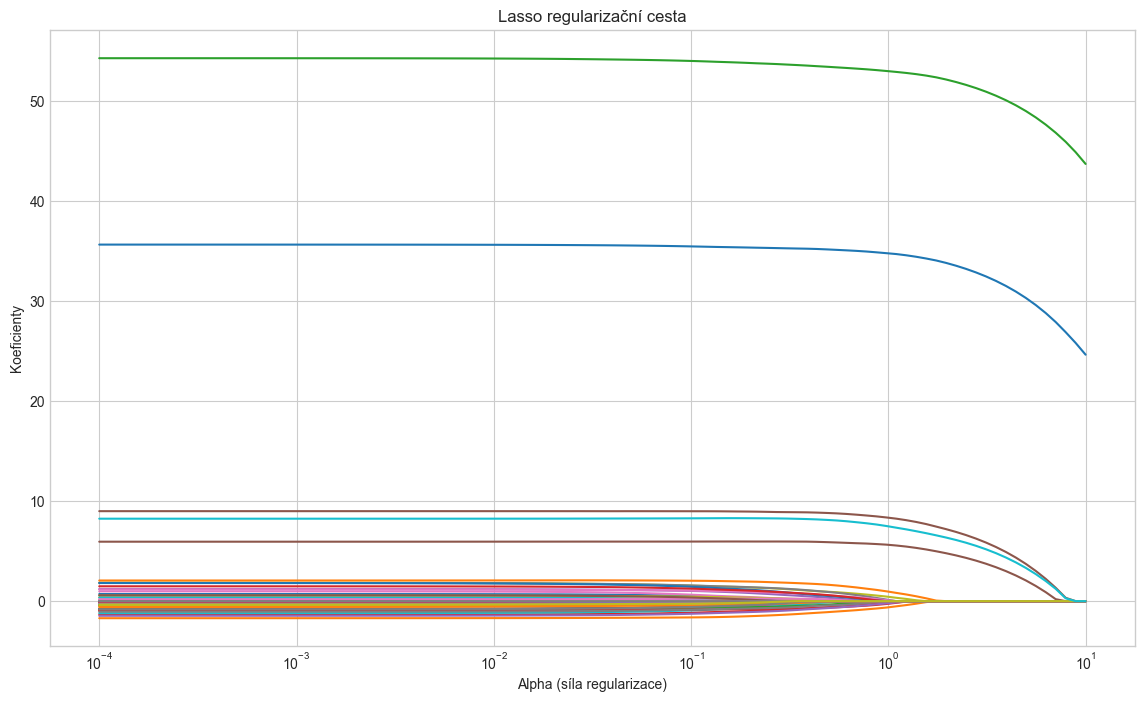

In [5]:
# Vizualizace regularizační cesty (jak se koeficienty mění s alpha)
alphas_path = np.logspace(-4, 1, 100)
coefs_path = []

for alpha in alphas_path:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    coefs_path.append(lasso.coef_)

coefs_path = np.array(coefs_path)

plt.figure(figsize=(14, 8))
plt.semilogx(alphas_path, coefs_path)
plt.xlabel('Alpha (síla regularizace)')
plt.ylabel('Koeficienty')
plt.title('Lasso regularizační cesta')
plt.axis('tight')
plt.grid(True)
plt.show()

## 2. Lasso na reálném datasetu

Použijeme California Housing dataset, který obsahuje informace o cenách domů v Kalifornii.

Dataset California Housing:
Tvar datasetu: (20640, 8)
Příznaky: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


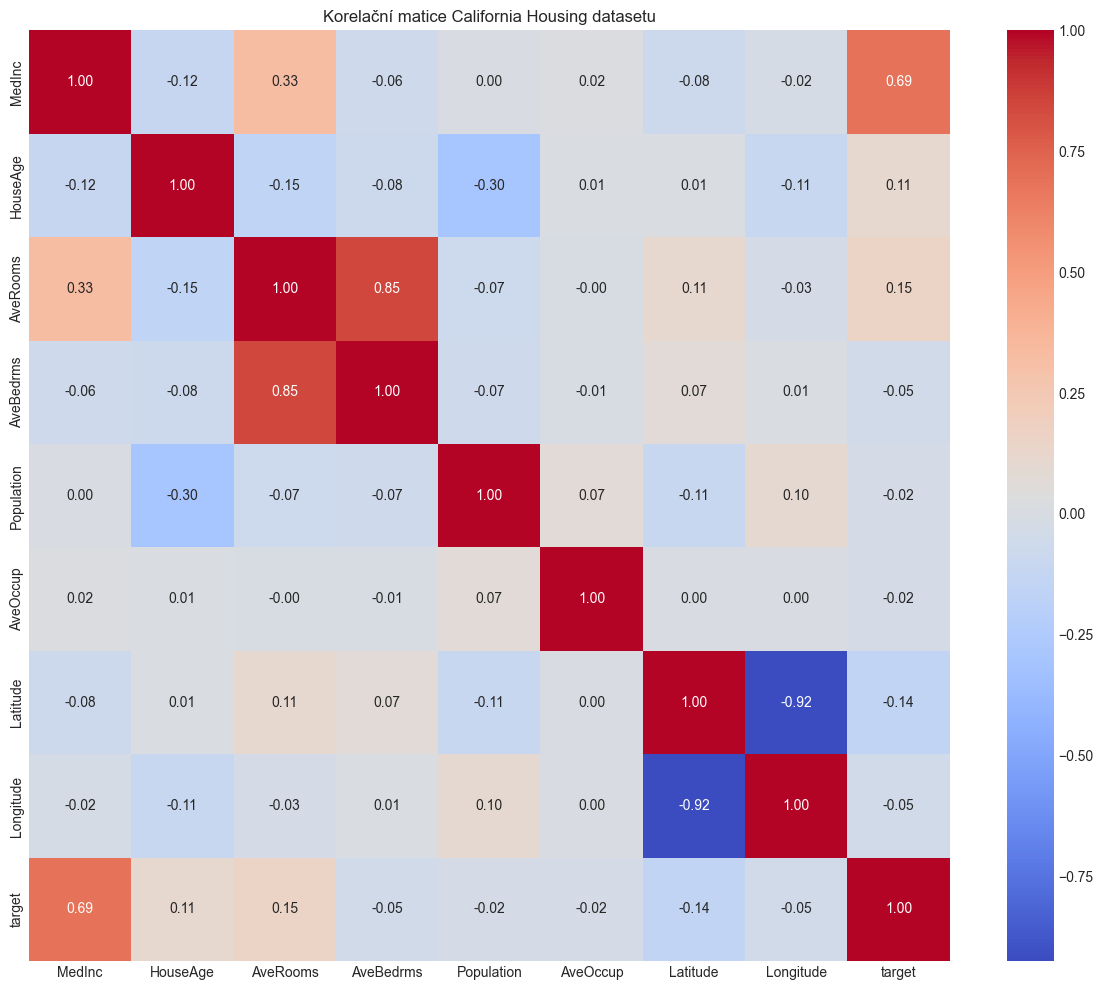

In [6]:
# Načtení datasetu California Housing
housing = fetch_california_housing()
X_housing, y_housing = housing.data, housing.target

# Základní informace o datasetu
print("Dataset California Housing:")
print(f"Tvar datasetu: {X_housing.shape}")
print(f"Příznaky: {housing.feature_names}")

# Rozdělení na trénovací a testovací sety
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Standardizace
scaler = StandardScaler()
X_train_h_scaled = scaler.fit_transform(X_train_h)
X_test_h_scaled = scaler.transform(X_test_h)

# Korelační matice pro pochopení dat
df_housing = pd.DataFrame(X_housing, columns=housing.feature_names)
df_housing['target'] = y_housing

plt.figure(figsize=(12, 10))
sns.heatmap(df_housing.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelační matice California Housing datasetu')
plt.tight_layout()
plt.show()

In [7]:
# Trénování a porovnání různých modelů
models = {
    'Lineární regrese': LinearRegression(),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01, random_state=42),
    'Lasso (alpha=0.1)': Lasso(alpha=0.1, random_state=42),
    'Lasso (alpha=1.0)': Lasso(alpha=1.0, random_state=42),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0, random_state=42),
    'ElasticNet (alpha=0.1)': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
}

results = []

for name, model in models.items():
    # Trénování
    start_time = time.time()
    model.fit(X_train_h_scaled, y_train_h)
    train_time = time.time() - start_time
    
    # Predikce
    y_pred = model.predict(X_test_h_scaled)
    
    # Metriky
    mse = mean_squared_error(y_test_h, y_pred)
    r2 = r2_score(y_test_h, y_pred)
    
    # Počet nenulových koeficientů
    if hasattr(model, 'coef_'):
        n_nonzero = np.sum(model.coef_ != 0)
    else:
        n_nonzero = X_train_h.shape[1]  # Všechny příznaky pro modely bez koeficientů
    
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R²': r2,
        'Nenulové koef.': n_nonzero,
        'Čas trénování (s)': train_time
    })

# Výpis výsledků
results_df = pd.DataFrame(results)
print("Porovnání modelů:")
print(results_df.round(4))

Porovnání modelů:
                    Model     MSE    RMSE      R²  Nenulové koef.  \
0        Lineární regrese  0.5559  0.7456  0.5758               8   
1      Lasso (alpha=0.01)  0.5483  0.7404  0.5816               7   
2       Lasso (alpha=0.1)  0.6796  0.8244  0.4814               3   
3       Lasso (alpha=1.0)  1.3107  1.1449 -0.0002               0   
4       Ridge (alpha=1.0)  0.5559  0.7456  0.5758               8   
5  ElasticNet (alpha=0.1)  0.6359  0.7974  0.5148               4   

   Čas trénování (s)  
0             0.0080  
1             0.0771  
2             0.0050  
3             0.0033  
4             0.0028  
5             0.0245  


<Figure size 1400x800 with 0 Axes>

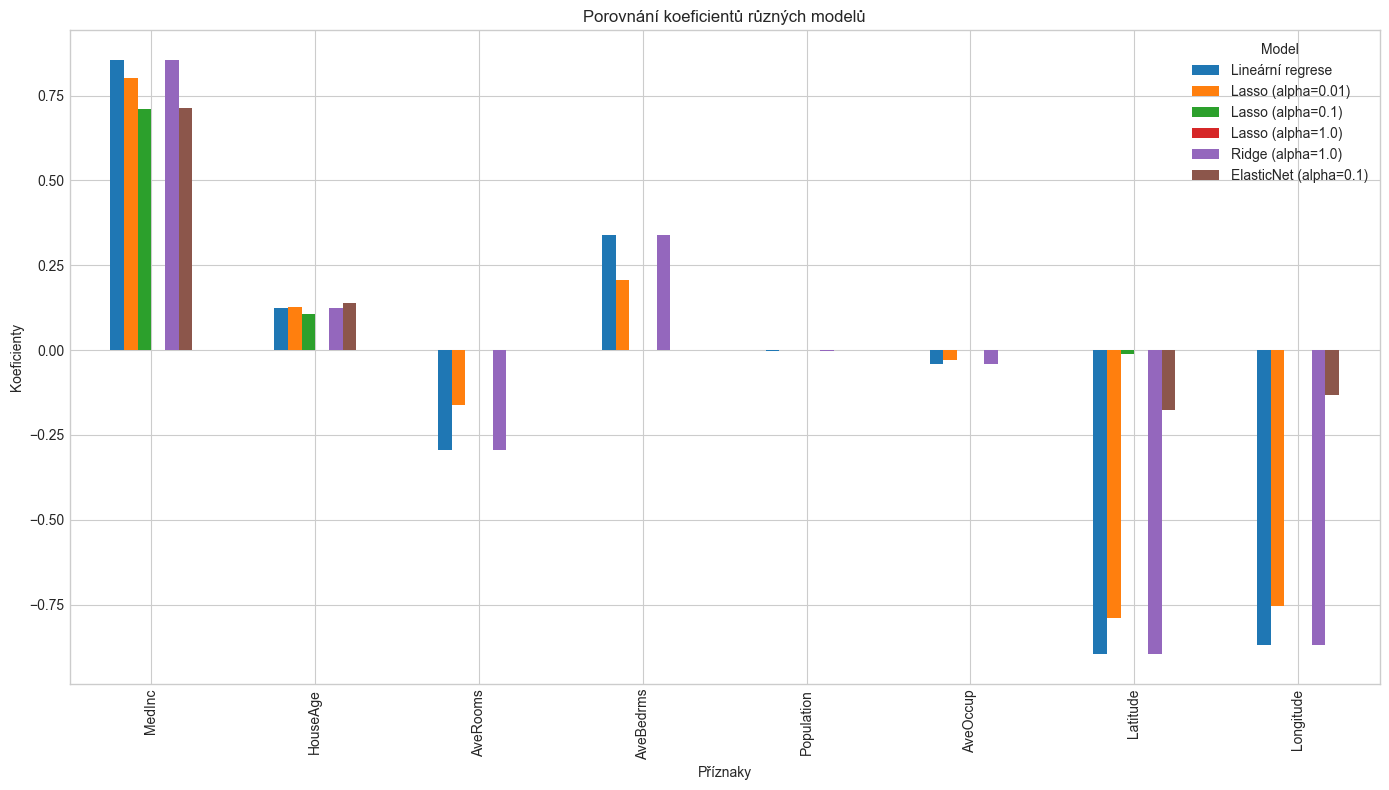

In [8]:
# Vizualizace koeficientů modelů
plt.figure(figsize=(14, 8))

# Extrakce koeficientů z modelů
coefs_models = {}
for name, model in models.items():
    if hasattr(model, 'coef_'):
        coefs_models[name] = model.coef_

# Příprava dat pro graf
df_coefs = pd.DataFrame(coefs_models, index=housing.feature_names)

# Vizualizace
ax = df_coefs.plot(kind='bar', figsize=(14, 8))
plt.title('Porovnání koeficientů různých modelů')
plt.xlabel('Příznaky')
plt.ylabel('Koeficienty')
plt.legend(title='Model')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Nalezení optimálního parametru alpha pomocí LassoCV

LassoCV provádí cross-validaci pro nalezení optimální hodnoty alpha.

In [9]:
# Použití LassoCV pro nalezení optimální hodnoty alpha
alphas_cv = np.logspace(-4, 1, 100)
lasso_cv = LassoCV(alphas=alphas_cv, cv=5, random_state=42, max_iter=10000)

# Trénování
lasso_cv.fit(X_train_h_scaled, y_train_h)

print(f"Optimální alpha nalezené pomocí cross-validace: {lasso_cv.alpha_:.6f}")

# Predikce s optimálním modelem
y_pred_cv = lasso_cv.predict(X_test_h_scaled)
mse_cv = mean_squared_error(y_test_h, y_pred_cv)
r2_cv = r2_score(y_test_h, y_pred_cv)

print(f"MSE s optimálním alpha: {mse_cv:.4f}")
print(f"R² s optimálním alpha: {r2_cv:.4f}")
print(f"Počet nenulových koeficientů: {np.sum(lasso_cv.coef_ != 0)}")

Optimální alpha nalezené pomocí cross-validace: 0.000643
MSE s optimálním alpha: 0.5550
R² s optimálním alpha: 0.5765
Počet nenulových koeficientů: 8


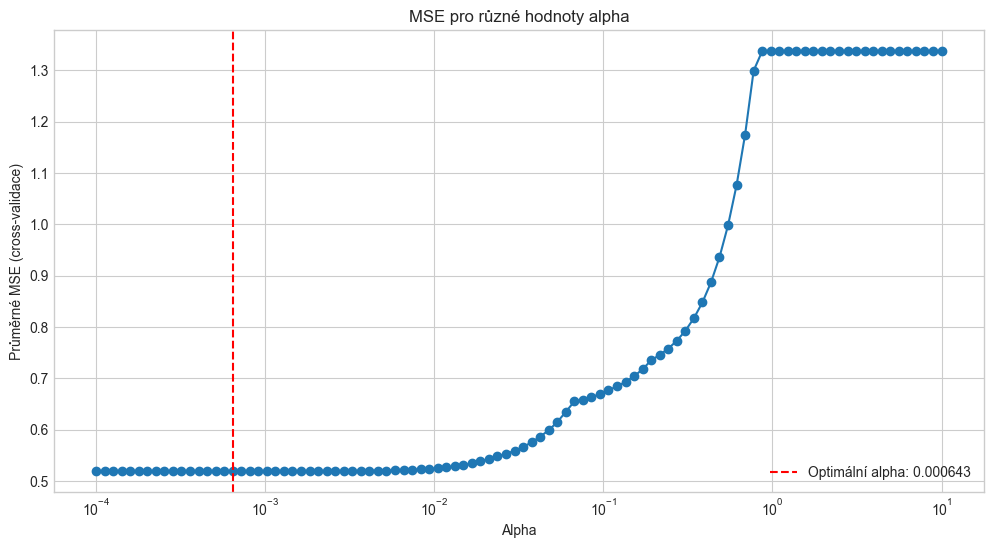

In [10]:
# Vizualizace MSE pro různé hodnoty alpha
plt.figure(figsize=(12, 6))
plt.semilogx(lasso_cv.alphas_, np.mean(lasso_cv.mse_path_, axis=1), marker='o', linestyle='-')
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Optimální alpha: {lasso_cv.alpha_:.6f}')
plt.xlabel('Alpha')
plt.ylabel('Průměrné MSE (cross-validace)')
plt.title('MSE pro různé hodnoty alpha')
plt.legend()
plt.grid(True)
plt.show()

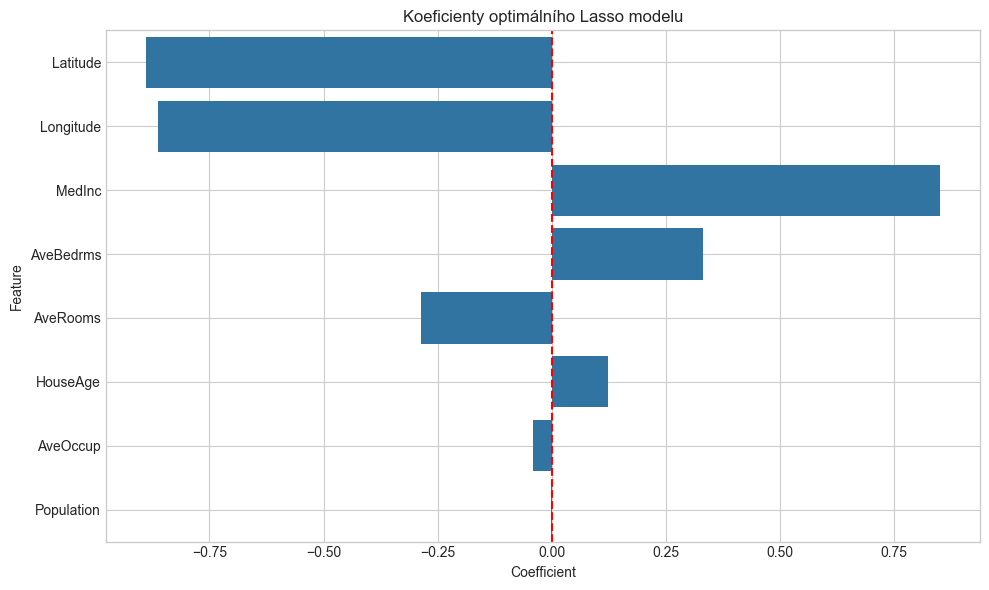

In [11]:
# Vizualizace koeficientů optimálního modelu
coef_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': lasso_cv.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Koeficienty optimálního Lasso modelu')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. Analýza a interpretace výsledků Lasso modelu

Lasso je užitečný nejen pro predikci, ale také pro interpretaci dat a pochopení důležitosti jednotlivých příznaků.

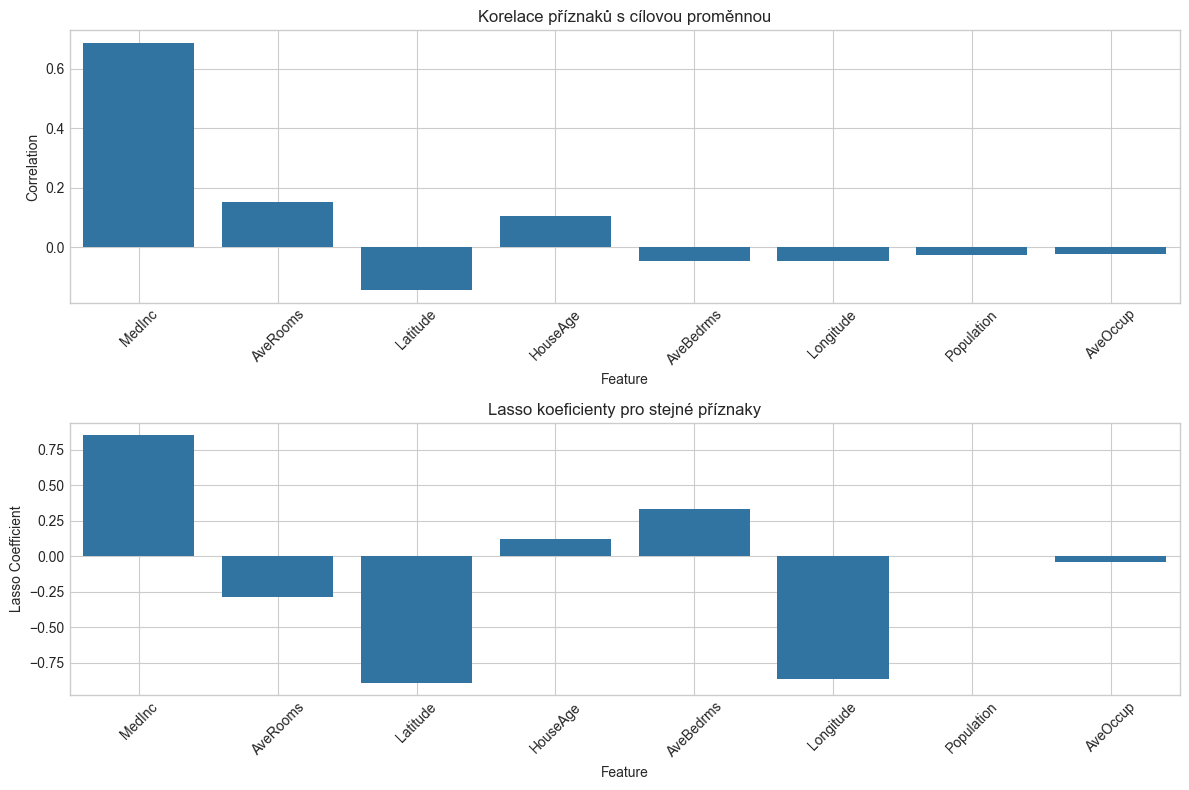

In [12]:
# Důkladná analýza významu příznaků

# Korelace příznaků s cílovou proměnnou
correlations = [np.corrcoef(X_housing[:, i], y_housing)[0, 1] for i in range(X_housing.shape[1])]
corr_df = pd.DataFrame({
    'Feature': housing.feature_names,
    'Correlation': correlations,
    'Lasso Coefficient': lasso_cv.coef_
}).sort_values(by='Correlation', key=abs, ascending=False)

# Vizualizace korelací vs. Lasso koeficientů
plt.figure(figsize=(12, 8))

# Dvojitý graf: korelace a koeficienty
ax1 = plt.subplot(2, 1, 1)
sns.barplot(x='Feature', y='Correlation', data=corr_df, ax=ax1)
plt.title('Korelace příznaků s cílovou proměnnou')
plt.xticks(rotation=45)
plt.grid(True)

ax2 = plt.subplot(2, 1, 2)
sns.barplot(x='Feature', y='Lasso Coefficient', data=corr_df, ax=ax2)
plt.title('Lasso koeficienty pro stejné příznaky')
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

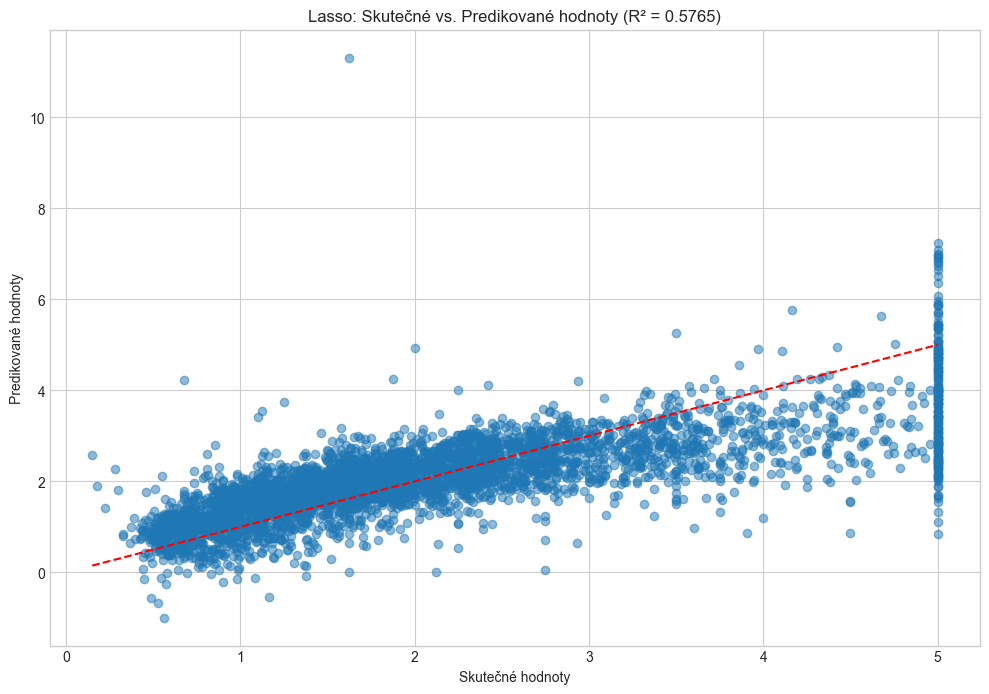

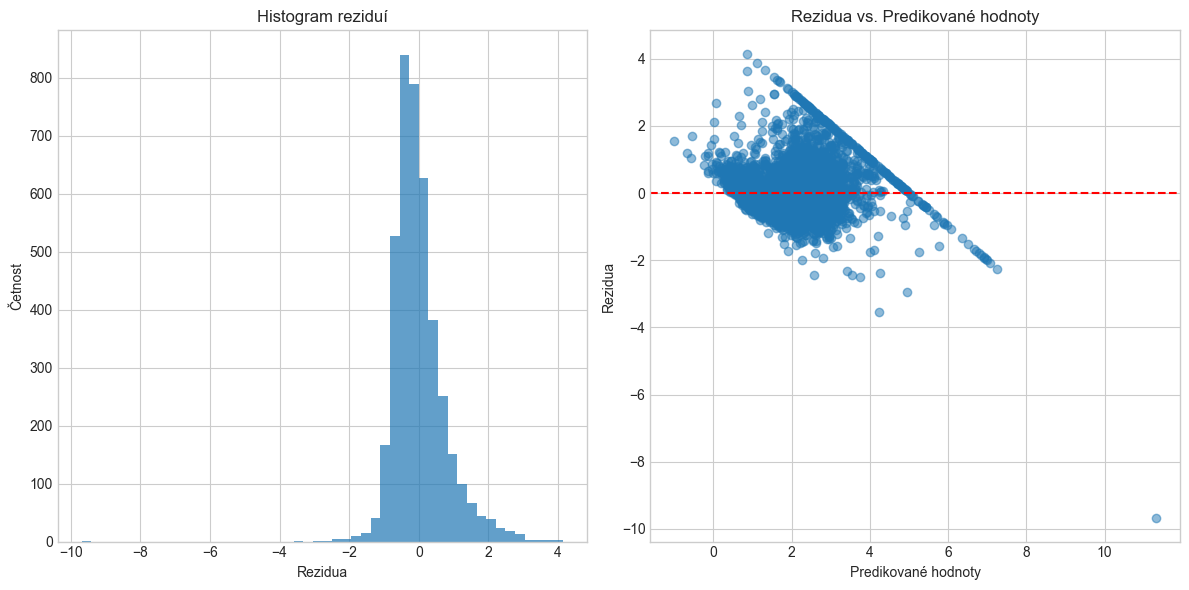

In [13]:
# Vizualizace predikce vs. skutečné hodnoty
plt.figure(figsize=(12, 8))

# Skutečné vs. predikované hodnoty
plt.scatter(y_test_h, y_pred_cv, alpha=0.5)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--')
plt.xlabel('Skutečné hodnoty')
plt.ylabel('Predikované hodnoty')
plt.title(f'Lasso: Skutečné vs. Predikované hodnoty (R² = {r2_cv:.4f})')
plt.grid(True)
plt.show()

# Histogram reziduí
residuals = y_test_h - y_pred_cv

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=50, alpha=0.7)
plt.xlabel('Rezidua')
plt.ylabel('Četnost')
plt.title('Histogram reziduí')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_pred_cv, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predikované hodnoty')
plt.ylabel('Rezidua')
plt.title('Rezidua vs. Predikované hodnoty')
plt.grid(True)

plt.tight_layout()
plt.show()

## 4. Praktické využití Lasso regrese a výběr příznaků

Ukážeme si, jak využít Lasso pro výběr příznaků a následně trénovat jiný model pouze s vybranými příznaky.

In [14]:
# Použití Lasso pro výběr příznaků
lasso_selector = Lasso(alpha=0.01, random_state=42)
lasso_selector.fit(X_train_h_scaled, y_train_h)

# Výběr příznaků s nenulovými koeficienty
selected_features = np.where(lasso_selector.coef_ != 0)[0]
selected_names = [housing.feature_names[i] for i in selected_features]

print(f"Lasso vybral {len(selected_features)} příznaků z celkových {len(housing.feature_names)}:")
print(f"Vybrané příznaky: {selected_names}")

# Vytvoření nových datasetů pouze s vybranými příznaky
X_train_selected = X_train_h_scaled[:, selected_features]
X_test_selected = X_test_h_scaled[:, selected_features]

# Trénování lineární regrese na zredukovaném datasetu
lr_selected = LinearRegression()
lr_selected.fit(X_train_selected, y_train_h)

# Predikce
y_pred_selected = lr_selected.predict(X_test_selected)
mse_selected = mean_squared_error(y_test_h, y_pred_selected)
r2_selected = r2_score(y_test_h, y_pred_selected)

print("\nVýsledky lineární regrese s vybranými příznaky:")
print(f"MSE: {mse_selected:.4f}")
print(f"R²: {r2_selected:.4f}")

Lasso vybral 7 příznaků z celkových 8:
Vybrané příznaky: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude']

Výsledky lineární regrese s vybranými příznaky:
MSE: 0.5560
R²: 0.5757


In [15]:
# Porovnání výsledků před a po výběru příznaků
comparison = pd.DataFrame([
    {'Model': 'Lineární regrese (všechny příznaky)', 
     'Počet příznaků': X_train_h.shape[1], 
     'MSE': mean_squared_error(y_test_h, models['Lineární regrese'].predict(X_test_h_scaled)), 
     'R²': r2_score(y_test_h, models['Lineární regrese'].predict(X_test_h_scaled))},
    {'Model': 'Lasso regrese', 
     'Počet příznaků': np.sum(lasso_cv.coef_ != 0), 
     'MSE': mse_cv, 
     'R²': r2_cv},
    {'Model': 'Lineární regrese (vybrané příznaky)', 
     'Počet příznaků': len(selected_features), 
     'MSE': mse_selected, 
     'R²': r2_selected}
])

print("Porovnání modelů po výběru příznaků:")
print(comparison.round(4))

Porovnání modelů po výběru příznaků:
                                 Model  Počet příznaků     MSE      R²
0  Lineární regrese (všechny příznaky)               8  0.5559  0.5758
1                        Lasso regrese               8  0.5550  0.5765
2  Lineární regrese (vybrané příznaky)               7  0.5560  0.5757


## 5. Lasso vs. jiné regresní techniky - kdy a proč používat Lasso

Pojďme porovnat Lasso s jinými regresními technikami na datech s vysokou dimenzionalitou a multikolinearitou.

In [16]:
# Vytvoření syntetických dat s vysokou dimenzí a silnou multikolinearitou
def create_multicollinear_data(n_samples=200, n_features=100, n_informative=10, noise=10, random_state=42):
    """Vytvoří dataset se silně korelovanými příznaky"""
    X, y = make_regression(n_samples=n_samples,
                          n_features=n_features,
                          n_informative=n_informative,
                          noise=noise,
                          random_state=random_state)
    
    # Přidání multikolinearity: každý pátý příznak je lineární kombinací předchozích
    rng = np.random.RandomState(random_state)
    for i in range(5, n_features, 5):
        X[:, i] = 0.3 * X[:, i-1] + 0.4 * X[:, i-2] + 0.3 * X[:, i-3] + rng.normal(0, 0.1, n_samples)
    
    return X, y

# Vytvoření dat
X_high_dim, y_high_dim = create_multicollinear_data(n_samples=200, n_features=100)

# Rozdělení na trénovací a testovací data
X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X_high_dim, y_high_dim, test_size=0.2, random_state=42
)

# Standardizace
scaler_hd = StandardScaler()
X_train_hd_scaled = scaler_hd.fit_transform(X_train_hd)
X_test_hd_scaled = scaler_hd.transform(X_test_hd)

In [17]:
# Porovnání modelů na datech s vysokou dimenzionalitou
models_high_dim = {
    'Lineární regrese': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
}

results_hd = []

for name, model in models_high_dim.items():
    try:
        # Trénování
        start_time = time.time()
        model.fit(X_train_hd_scaled, y_train_hd)
        train_time = time.time() - start_time
        
        # Predikce
        y_pred = model.predict(X_test_hd_scaled)
        
        # Metriky
        mse = mean_squared_error(y_test_hd, y_pred)
        r2 = r2_score(y_test_hd, y_pred)
        
        # Počet nenulových koeficientů
        if hasattr(model, 'coef_'):
            n_nonzero = np.sum(model.coef_ != 0)
        else:
            n_nonzero = X_train_hd.shape[1]  # Všechny příznaky pro modely bez koeficientů
        
        results_hd.append({
            'Model': name,
            'MSE': mse,
            'R²': r2,
            'Nenulové koef.': n_nonzero,
            'Čas trénování (s)': train_time
        })
    except Exception as e:
        print(f"Chyba při trénování modelu {name}: {e}")
        results_hd.append({
            'Model': name,
            'MSE': np.nan,
            'R²': np.nan,
            'Nenulové koef.': np.nan,
            'Čas trénování (s)': np.nan
        })

# Výpis výsledků
results_hd_df = pd.DataFrame(results_hd)
print("Porovnání modelů na datech s vysokou dimenzionalitou:")
print(results_hd_df.round(4))

Porovnání modelů na datech s vysokou dimenzionalitou:
              Model        MSE      R²  Nenulové koef.  Čas trénování (s)
0  Lineární regrese  1540.0749  0.9546             100              0.013
1             Ridge  1426.2722  0.9579             100              0.003
2             Lasso  1359.3799  0.9599             100              0.015
3        ElasticNet  1390.7488  0.9590              98              0.008


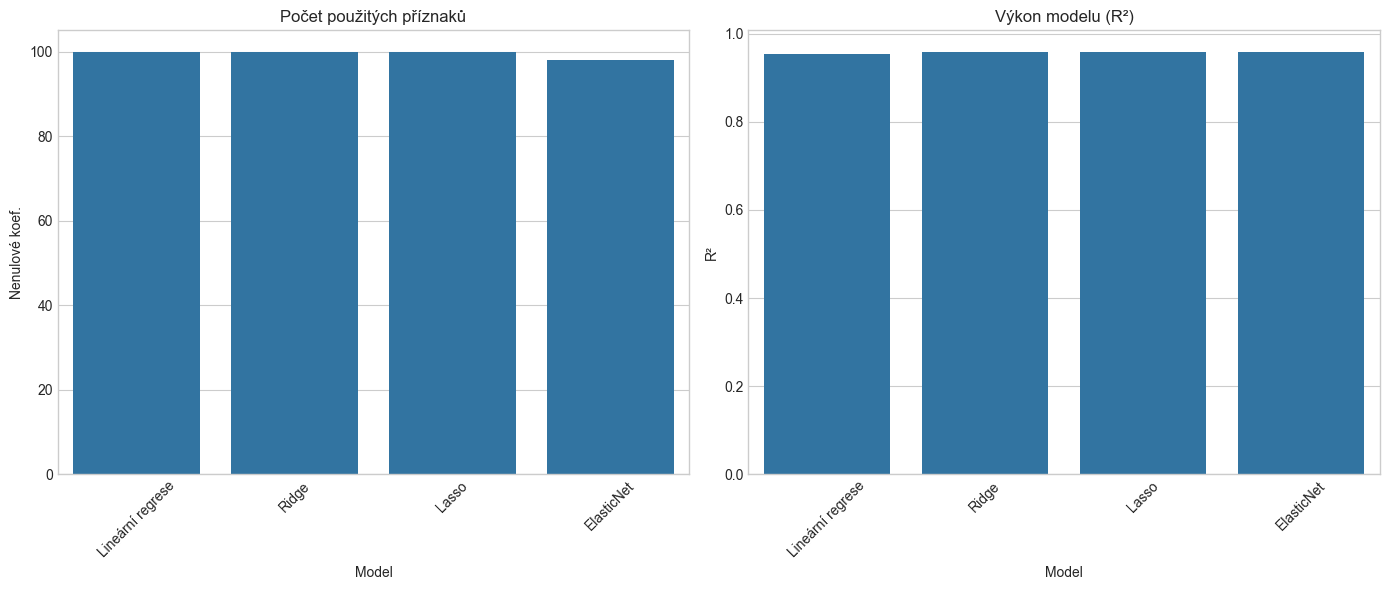

In [18]:
# Vizualizace počtu vybraných příznaků a výkonu modelů
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Nenulové koef.', data=results_hd_df)
plt.title('Počet použitých příznaků')
plt.xticks(rotation=45)
plt.grid(True, axis='y')

plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R²', data=results_hd_df)
plt.title('Výkon modelu (R²)')
plt.xticks(rotation=45)
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

## 6. Shrnutí a nejlepší praktiky pro použití Lasso

### Kdy použít Lasso:

1. **Pro výběr příznaků** - Když máte mnoho příznaků a chcete identifikovat ty nejdůležitější
2. **Pro řídké modely** - Když chcete vytvořit jednoduchý, interpretovatelný model
3. **Pro vysokodimenzionální data** - Zejména když počet příznaků převyšuje počet vzorků
4. **Při multikolinearitě** - Lasso má tendenci vybrat jeden příznak z korelované skupiny

### Praktické tipy pro použití Lasso:

1. **Vždy standardizujte příznaky** - Lasso je citlivé na měřítko příznaků
2. **Hledejte optimální alpha pomocí cross-validace** - Použijte LassoCV
3. **Kontrolujte stabilitu výběru příznaků** - Opakujte trénování na různých podmnožinách dat
4. **Sledujte regularizační cestu** - Jak se koeficienty mění s různými hodnotami alpha
5. **Kombinujte s jinými metodami** - Např. použijte Lasso pro výběr příznaků a pak jiný model

### Výhody Lasso:

- Automatický výběr příznaků (nastavuje některé koeficienty přesně na nulu)
- Jednoduchost a interpretabilita výsledných modelů
- Efektivní pro vysokodimenzionální data
- Zabudovaná regularizace pro prevenci přeučení

### Nevýhody Lasso:

- Problémy při silné multikolinearitě (náhodně vybere jeden z korelovaných příznaků)
- Nestabilita výběru příznaků při malých změnách dat
- Může trpět problémy s konvergencí při některých hodnotách alpha
- Není vhodné, pokud všechny příznaky mají být skutečně relevantní

Lasso regrese je výkonný nástroj pro vytváření jednoduchých modelů s automatickým výběrem příznaků. Správně použitá může výrazně zlepšit interpretabilitu modelu a snížit riziko přeučení, zejména při práci s vysokodimenzionálními daty.